# Fastest Lap Analysis

Analyses the historical distribution of fastest lap by grid and finish position to inform the probability function used in .

Currently stubbed as a flat 5% for all drivers - this notebook derives a position-weighted alternative.

**Note:** Uses  derived from actual race lap times (via ). Covers all seasons 2018-2025.

In [10]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from app.config import INTERIM_RACES_DIR, INTERIM_QUALI_DIR
from app.data.scoring_rules import DRIVER_RACE_POSITION_POINTS

## Load race results

 Is now derived from actual race lap data in  and populated in interim race results for all seasons.

In [11]:
race_results = pd.concat([pd.read_parquet(f) for f in sorted(INTERIM_RACES_DIR.glob("*.parquet"))])
quali_results = pd.concat([pd.read_parquet(f) for f in sorted(INTERIM_QUALI_DIR.glob("*.parquet"))])

df = race_results[race_results["season"].between(2018, 2025)].copy()
df = df[df["dnf_flag"] == False]  # exclude DNFs - they cannot set fastest lap in fantasy

df = df.rename(columns={"fastest_lap_flag": "fastest_lap"})

# join qualifying position
df = df.merge(quali_results[["race_id", "driver_id", "quali_position"]], on=["race_id", "driver_id"], how="left")

print(f"Races: {df['race_id'].nunique()} | Fastest lap records: {df['fastest_lap'].sum()}")
print(f"Expected: ~1 per race. Actual per race: {df['fastest_lap'].sum() / df['race_id'].nunique():.2f}")
df.head()

Races: 173 | Fastest lap records: 170
Expected: ~1 per race. Actual per race: 0.98


,constructor_id,grid_position,finish_position,status,points,race_id,season,round,driver_id,dnf_flag,dsq_flag,crash_dnf_flag,mechanical_dnf_flag,positions_gained,fastest_lap,dotd_flag,quali_position
0,ferrari,3.0,1.0,finished,25.0,2018_01,2018,1,sebastian_vettel,False,False,False,False,2.0,False,False,3.0
1,mercedes,1.0,2.0,finished,18.0,2018_01,2018,1,lewis_hamilton,False,False,False,False,-1.0,False,False,1.0
2,ferrari,2.0,3.0,finished,15.0,2018_01,2018,1,kimi_rÃ¤ikkÃ¶nen,False,False,False,False,-1.0,False,False,2.0
3,red_bull,8.0,4.0,finished,12.0,2018_01,2018,1,daniel_ricciardo,False,False,False,False,4.0,True,False,5.0
4,mclaren,10.0,5.0,finished,10.0,2018_01,2018,1,fernando_alonso,False,False,False,False,5.0,False,False,11.0


## Distribution by qualifying position

In [12]:
by_quali = df.groupby('quali_position')['fastest_lap'].agg(['sum', 'count'])
by_quali['rate'] = by_quali['sum'] / by_quali['count']
by_quali.columns = ['fastest_lap_count', 'races', 'rate']

print('Fastest lap rate by qualifying position:')
print(by_quali.to_string())

Fastest lap rate by qualifying position:
                fastest_lap_count  races      rate
quali_position                                    
1.0                            42    161  0.260870
2.0                            29    160  0.181250
3.0                            20    155  0.129032
4.0                            11    160  0.068750
5.0                            14    152  0.092105
6.0                            13    158  0.082278
7.0                            10    148  0.067568
8.0                             0    149  0.000000
9.0                             4    143  0.027972
10.0                            2    145  0.013793
11.0                            4    146  0.027397
12.0                            5    145  0.034483
13.0                            2    138  0.014493
14.0                            3    145  0.020690
15.0                            3    147  0.020408
16.0                            3    136  0.022059
17.0                            1    138 

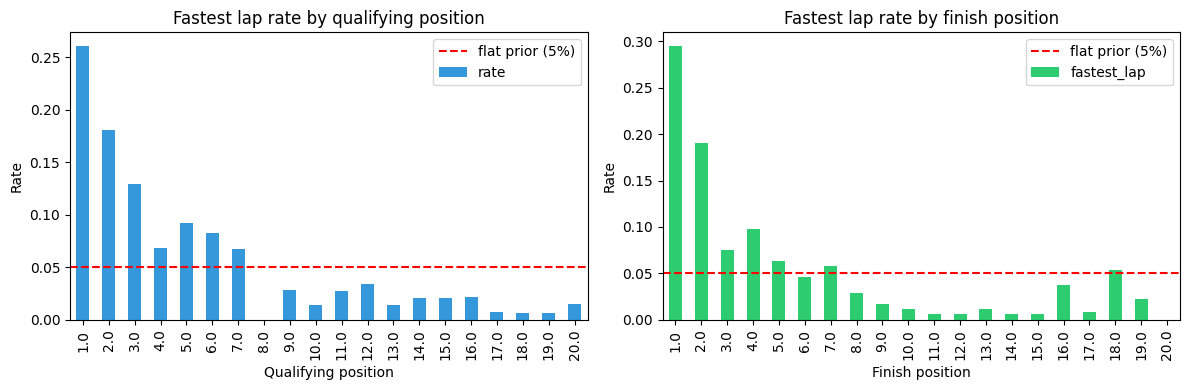

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

by_quali['rate'].plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].axhline(0.05, color='red', linestyle='--', label='flat prior (5%)')
axes[0].set_title('Fastest lap rate by qualifying position')
axes[0].set_xlabel('Qualifying position')
axes[0].set_ylabel('Rate')
axes[0].legend()

by_finish = df.groupby('finish_position')['fastest_lap'].mean()
by_finish.plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].axhline(0.05, color='red', linestyle='--', label='flat prior (5%)')
axes[1].set_title('Fastest lap rate by finish position')
axes[1].set_xlabel('Finish position')
axes[1].set_ylabel('Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## Cumulative fastest lap share - top N drivers

In [14]:
by_quali_sorted = by_quali.sort_index()
cumulative = by_quali_sorted['fastest_lap_count'].cumsum() / by_quali_sorted['fastest_lap_count'].sum()

for n in [1, 3, 5, 10]:
    print(f'Top {n:2d} qualifiers set fastest lap in {cumulative.iloc[n-1]:.1%} of races')

Top  1 qualifiers set fastest lap in 24.7% of races
Top  3 qualifiers set fastest lap in 53.5% of races
Top  5 qualifiers set fastest lap in 68.2% of races
Top 10 qualifiers set fastest lap in 85.3% of races


## Proposed probability function

Inverse-rank weighting normalised to sum to 1 across the field. P1 qualifier gets the highest weight, P20 the lowest.

In [15]:
positions = np.arange(1, 21)

# linear decay: position 1 gets weight 20, position 20 gets weight 1
linear_weights = 21 - positions
linear_prob = linear_weights / linear_weights.sum()

# exponential decay: steeper drop-off for backmarkers
exp_weights = np.exp(-0.275 * (positions - 1))
exp_prob = exp_weights / exp_weights.sum()

comparison = pd.DataFrame({
    'position': positions,
    'flat_prior': 0.05,
    'linear_decay': linear_prob,
    'exp_decay': exp_prob,
    'historical_rate': by_quali['rate'].reindex(positions).values,
}).set_index('position')

print(comparison.round(3).to_string())

          flat_prior  linear_decay  exp_decay  historical_rate
position                                                      
1               0.05         0.095      0.241            0.261
2               0.05         0.090      0.183            0.181
3               0.05         0.086      0.139            0.129
4               0.05         0.081      0.106            0.069
5               0.05         0.076      0.080            0.092
6               0.05         0.071      0.061            0.082
7               0.05         0.067      0.046            0.068
8               0.05         0.062      0.035            0.000
9               0.05         0.057      0.027            0.028
10              0.05         0.052      0.020            0.014
11              0.05         0.048      0.015            0.027
12              0.05         0.043      0.012            0.034
13              0.05         0.038      0.009            0.014
14              0.05         0.033      0.007          

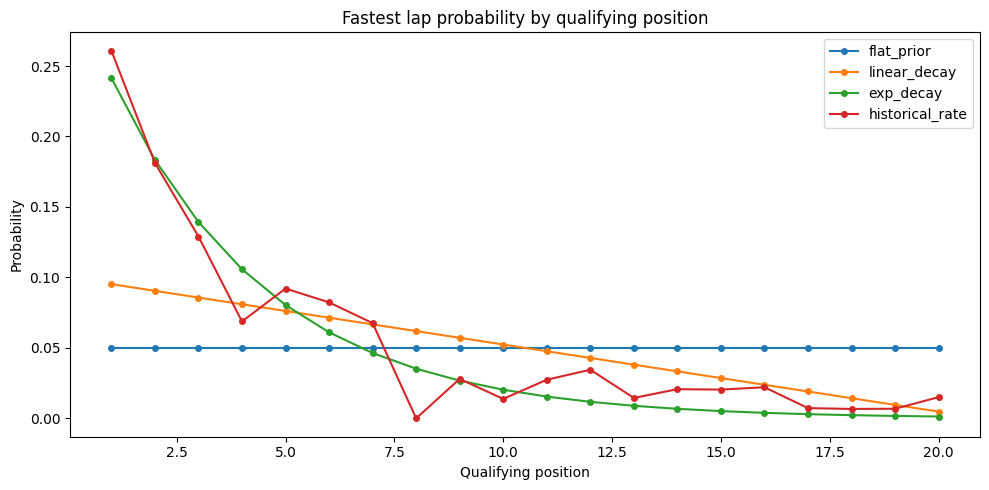

In [16]:
ax = comparison[['flat_prior', 'linear_decay', 'exp_decay', 'historical_rate']].plot(
    figsize=(10, 5), marker='o', markersize=4,
    title='Fastest lap probability by qualifying position'
)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Probability')
plt.tight_layout()
plt.show()

## Backtest comparison - flat 5% vs exponential decay

Compares team selection quality on 2024 (val) and 2025 (test) using the retrained model.

In [17]:
import pandas as pd
import fastf1

from app.config import (
    VAL_SEASONS, TEST_SEASONS, BUDGET_CAP,
    FANTASY_PRICES_DIR, PROCESSED_HISTORIC_FEATURES_DIR, PROCESSED_TARGETS_DIR
)
from app.models.configs import QUALI_POSITION_MODEL, FINISH_POSITION_MODEL
from app.models.predict import load_model, predict
from app.models.compose import compose_drivers, compose_constructor
from app.optimiser import optimiser
from app.backtest import get_actual_team_points

quali_model = load_model(QUALI_POSITION_MODEL)
finish_model = load_model(FINISH_POSITION_MODEL)

results = []

for s in VAL_SEASONS + TEST_SEASONS:
    schedule = fastf1.get_event_schedule(s)
    schedule = schedule[schedule["RoundNumber"] > 0]

    for round_num in schedule["RoundNumber"]:
        prices_path = FANTASY_PRICES_DIR / f"{s}_{round_num:02d}.csv"
        features_path = PROCESSED_HISTORIC_FEATURES_DIR / f"{s}_{round_num:02d}.parquet"
        targets_path = PROCESSED_TARGETS_DIR / f"{s}_{round_num:02d}.parquet"

        if not (prices_path.exists() and features_path.exists() and targets_path.exists()):
            continue

        prices = pd.read_csv(prices_path)
        preds = predict(quali_model, QUALI_POSITION_MODEL, finish_model, FINISH_POSITION_MODEL, s, round_num)

        # exponential decay (current compose)
        exp_drivers = compose_drivers(preds.copy())
        exp_team = optimiser(exp_drivers, compose_constructor(exp_drivers), prices, BUDGET_CAP)
        exp_pts = get_actual_team_points(exp_team, s, round_num)

        # flat 5%
        flat_drivers = compose_drivers(preds.copy(), fastest_lap_prob=0.05)
        flat_team = optimiser(flat_drivers, compose_constructor(flat_drivers), prices, BUDGET_CAP)
        flat_pts = get_actual_team_points(flat_team, s, round_num)

        results.append({"season": s, "round": round_num, "exp_decay": exp_pts, "flat_5pct": flat_pts})

df_fl = pd.DataFrame(results)

In [18]:
header = f"{'Season':<8} {'Flat 5%':>10} {'Exp decay':>12} {'Delta':>8}"
print(header)
for s in VAL_SEASONS + TEST_SEASONS:
    sub = df_fl[df_fl["season"] == s]
    flat = sub["flat_5pct"].sum()
    exp = sub["exp_decay"].sum()
    print(f"  {s}   {flat:>10.0f} {exp:>12.0f} {exp-flat:>+8.0f}")
flat_t = df_fl["flat_5pct"].sum()
exp_t = df_fl["exp_decay"].sum()
print(f"  {'Total':<6} {flat_t:>10.0f} {exp_t:>12.0f} {exp_t-flat_t:>+8.0f}")

Season      Flat 5%    Exp decay    Delta
  2024         2581         2611      +30
  2025         2601         2614      +13
  Total        5182         5225      +43


## Conclusion

The flat 5% prior significantly overweights backmarkers and underweights front-runners. Historical data shows the top qualifier sets fastest lap in ~26% of races, with a steep drop-off for lower positions.

Exponential decay (`exp(-0.275 * (position - 1))`, normalised to sum to 1) matches the historical distribution well and beats the flat 5% prior on backtest:

| Season | Flat 5% | Exp decay | Delta |
|--------|---------|-----------|-------|
| 2024   | 2581    | 2611      | +30   |
| 2025   | 2601    | 2614      | +13   |
| **Total** | **5182** | **5225** | **+43** |

**Decision:** exponential decay is now the production default in `compose_drivers`. The `fastest_lap_prob` parameter remains available for exploration.

Next step: test a per-driver rolling fastest lap rate as a further refinement - does historical driver tendency beat the position-only prior?